In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

CSV = r"C:\Users\Aman Karwal\Downloads\bluestock-mf-capstone\\"

fund_master  = pd.read_csv(CSV + "01_fund_master.csv")  # ← YEH ADD KIYA
nav          = pd.read_csv(CSV + "02_nav_history.csv")
aum          = pd.read_csv(CSV + "03_aum_by_fund_house.csv")
sip          = pd.read_csv(CSV + "04_monthly_sip_inflows.csv")
category     = pd.read_csv(CSV + "05_category_inflows.csv")
folio        = pd.read_csv(CSV + "06_industry_folio_count.csv")
performance  = pd.read_csv(CSV + "07_scheme_performance.csv")
transactions = pd.read_csv(CSV + "08_investor_transactions.csv")
holdings     = pd.read_csv(CSV + "09_portfolio_holdings.csv")

nav['date']       = pd.to_datetime(nav['date'])
sip['month']      = pd.to_datetime(sip['month'])
aum['date']       = pd.to_datetime(aum['date'])
category['month'] = pd.to_datetime(category['month'])
folio['month']    = pd.to_datetime(folio['month'])

print("✓ Sab load ho gaya!")
print(f"Fund Master: {len(fund_master)} funds")
print(f"NAV History: {len(nav):,} rows")
print(f"Transactions: {len(transactions):,} rows")

✓ Sab load ho gaya!
Fund Master: 40 funds
NAV History: 39,568 rows
Transactions: 10,982 rows


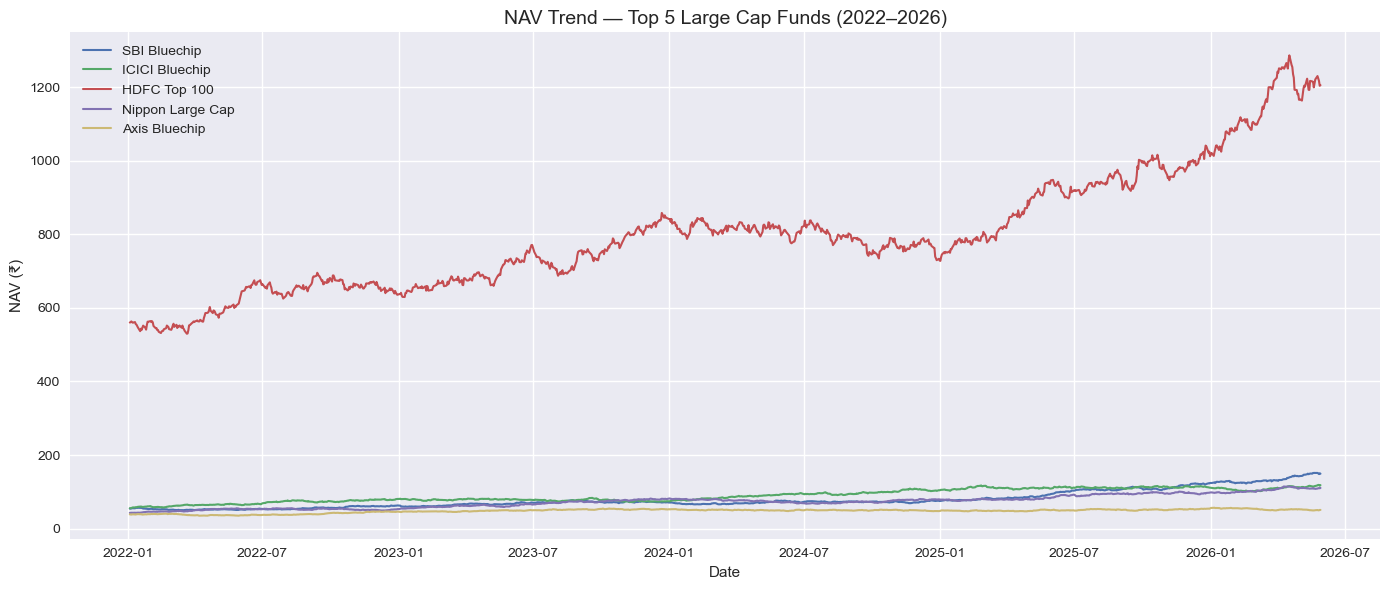

✓ Chart 1 done!


In [4]:
# NAV trend — 5 funds ka price 2022-2026 tak
top5 = {119551:'SBI Bluechip', 120503:'ICICI Bluechip',
        125497:'HDFC Top 100', 118632:'Nippon Large Cap',
        119092:'Axis Bluechip'}

plt.figure(figsize=(14,6))
for code, name in top5.items():
    d = nav[nav['amfi_code']==code]
    plt.plot(d['date'], d['nav'], label=name, linewidth=1.5)

plt.title('NAV Trend — Top 5 Large Cap Funds (2022–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('NAV (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('chart1_nav_trend.png', dpi=150)
plt.show()
print("✓ Chart 1 done!")

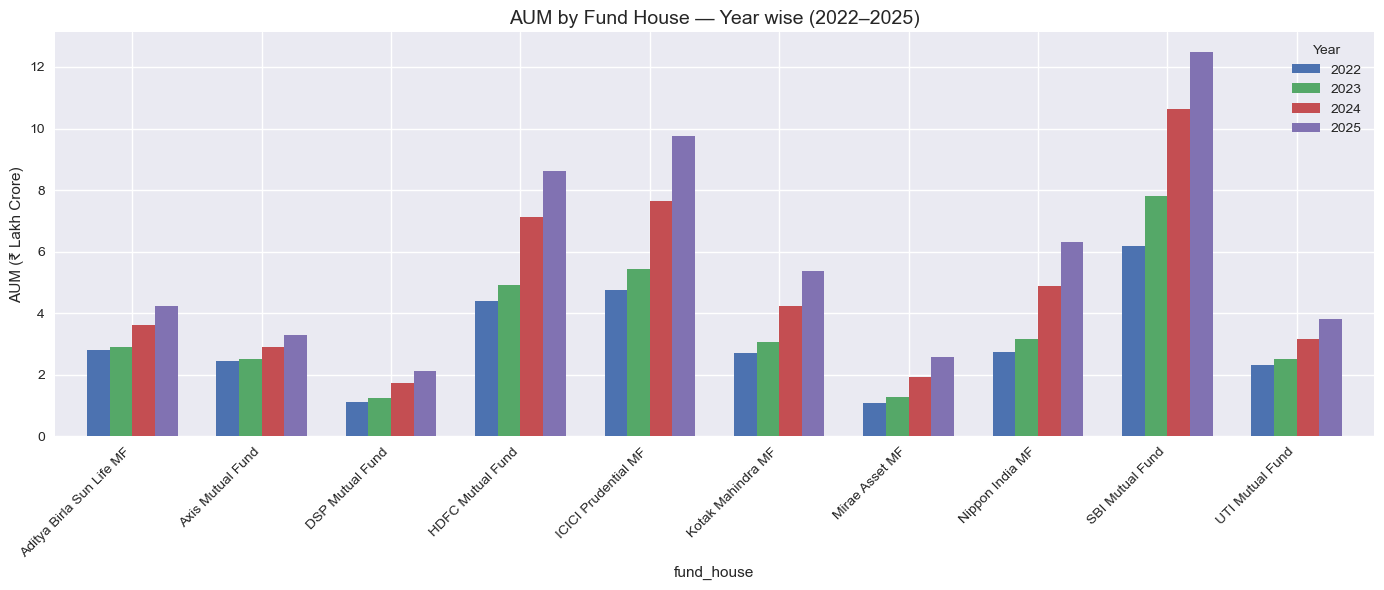

✓ Chart 2 done!


In [5]:
# AUM — har fund house ka year wise AUM
aum['year'] = aum['date'].dt.year
aum_y = aum.groupby(['fund_house','year'])['aum_lakh_crore'].mean().unstack()

aum_y.plot(kind='bar', figsize=(14,6), width=0.7)
plt.title('AUM by Fund House — Year wise (2022–2025)', fontsize=14)
plt.ylabel('AUM (₹ Lakh Crore)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('chart2_aum_growth.png', dpi=150)
plt.show()
print("✓ Chart 2 done!")

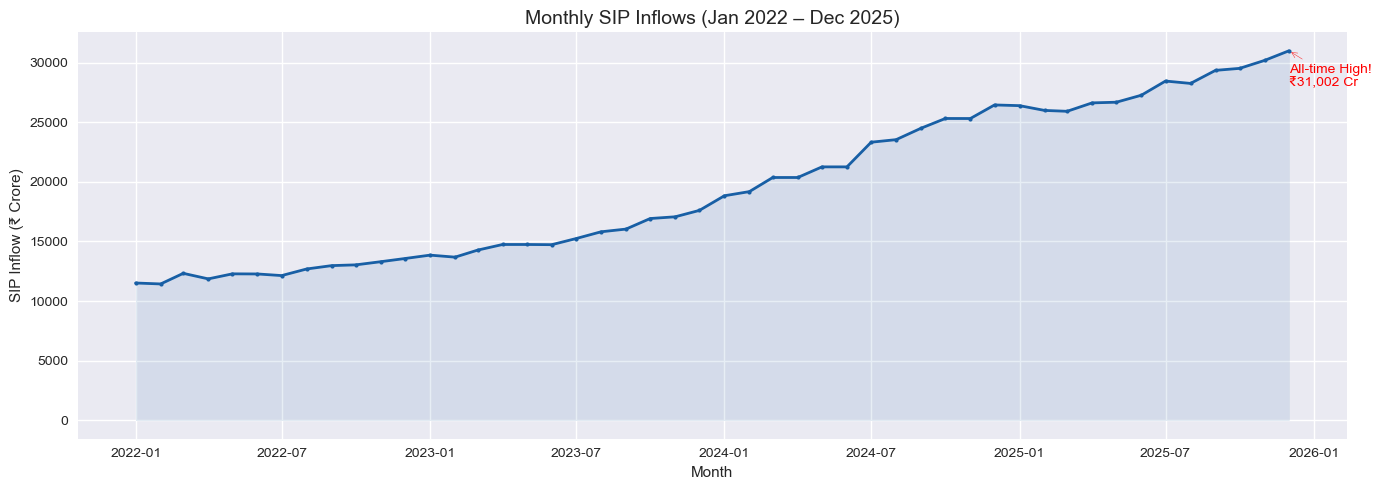

✓ Chart 3 done!


In [6]:
# SIP inflow trend + all time high mark
plt.figure(figsize=(14,5))
plt.plot(sip['month'], sip['sip_inflow_crore'],
         color='#185FA5', linewidth=2, marker='o', markersize=3)
plt.fill_between(sip['month'], sip['sip_inflow_crore'],
                 alpha=0.1, color='#185FA5')

max_val   = sip['sip_inflow_crore'].max()
max_month = sip.loc[sip['sip_inflow_crore'].idxmax(), 'month']
plt.annotate(f'All-time High!\n₹{max_val:,.0f} Cr',
             xy=(max_month, max_val),
             xytext=(max_month, max_val-3000),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.title('Monthly SIP Inflows (Jan 2022 – Dec 2025)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('SIP Inflow (₹ Crore)')
plt.tight_layout()
plt.savefig('chart3_sip_trend.png', dpi=150)
plt.show()
print("✓ Chart 3 done!")

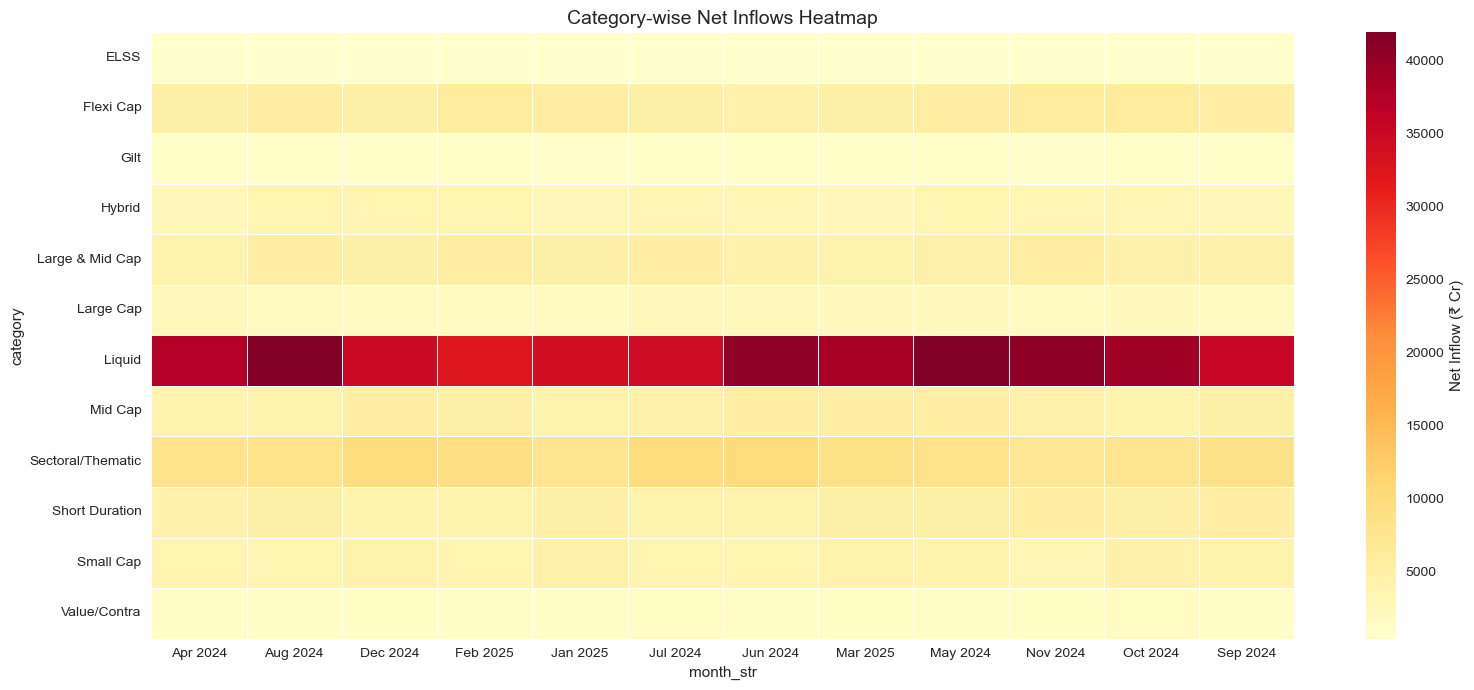

✓ Chart 4 done!


In [7]:
# Category inflow heatmap
category['month_str'] = category['month'].dt.strftime('%b %Y')
pivot = category.pivot(index='category',
                       columns='month_str',
                       values='net_inflow_crore')

plt.figure(figsize=(16,7))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label':'Net Inflow (₹ Cr)'})
plt.title('Category-wise Net Inflows Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('chart4_category_heatmap.png', dpi=150)
plt.show()
print("✓ Chart 4 done!")

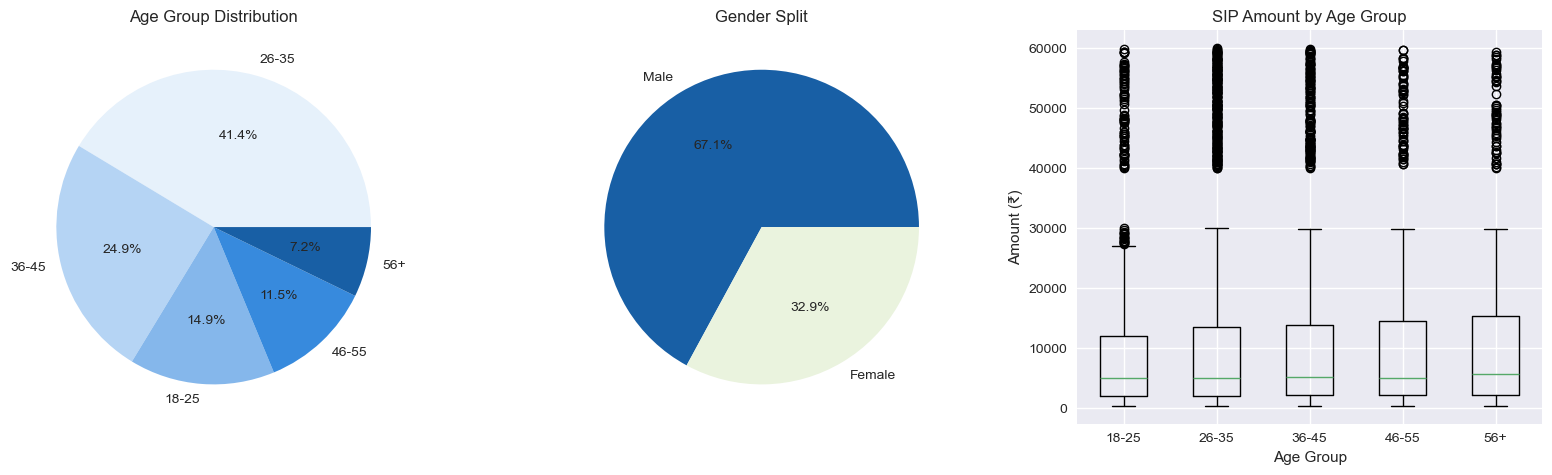

✓ Chart 5 & 6 done!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# Age group pie
age = transactions['age_group'].value_counts()
axes[0].pie(age.values, labels=age.index, autopct='%1.1f%%',
            colors=['#E6F1FB','#B5D4F4','#85B7EB','#378ADD','#185FA5'])
axes[0].set_title('Age Group Distribution')

# Gender pie
gender = transactions['gender'].value_counts()
axes[1].pie(gender.values, labels=gender.index, autopct='%1.1f%%',
            colors=['#185FA5','#EAF3DE'])
axes[1].set_title('Gender Split')

# SIP amount by age group — ORDER FIX KIYA
age_order = ['18-25','26-35','36-45','46-55','56+']
sip_tx = transactions[transactions['transaction_type']=='SIP']

data_ordered = [sip_tx[sip_tx['age_group']==age]['amount_inr'].dropna().values 
                for age in age_order]

axes[2].boxplot(data_ordered, labels=age_order)
axes[2].set_title('SIP Amount by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Amount (₹)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('chart5_demographics.png', dpi=150)
plt.show()
print("✓ Chart 5 & 6 done!")

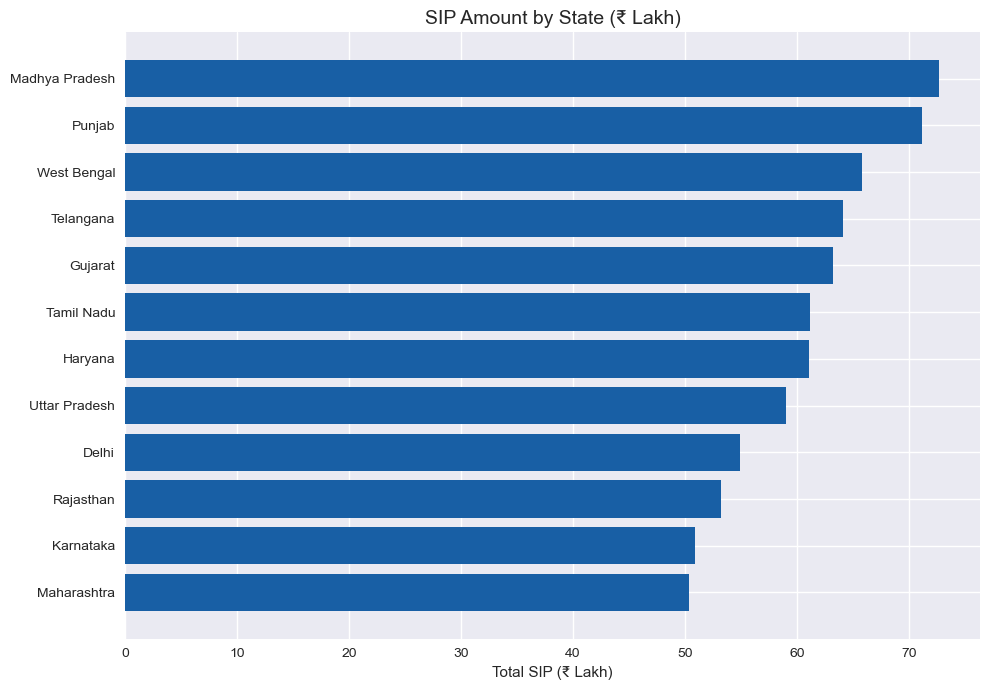

✓ Chart 7 done!


In [10]:
# State wise SIP amount
state_sip = (transactions[transactions['transaction_type']=='SIP']
             .groupby('state')['amount_inr']
             .sum()
             .sort_values(ascending=True))

plt.figure(figsize=(10,7))
plt.barh(state_sip.index, state_sip.values/100000, color='#185FA5')
plt.title('SIP Amount by State (₹ Lakh)', fontsize=14)
plt.xlabel('Total SIP (₹ Lakh)')
plt.tight_layout()
plt.savefig('chart6_state_sip.png', dpi=150)
plt.show()
print("✓ Chart 7 done!")

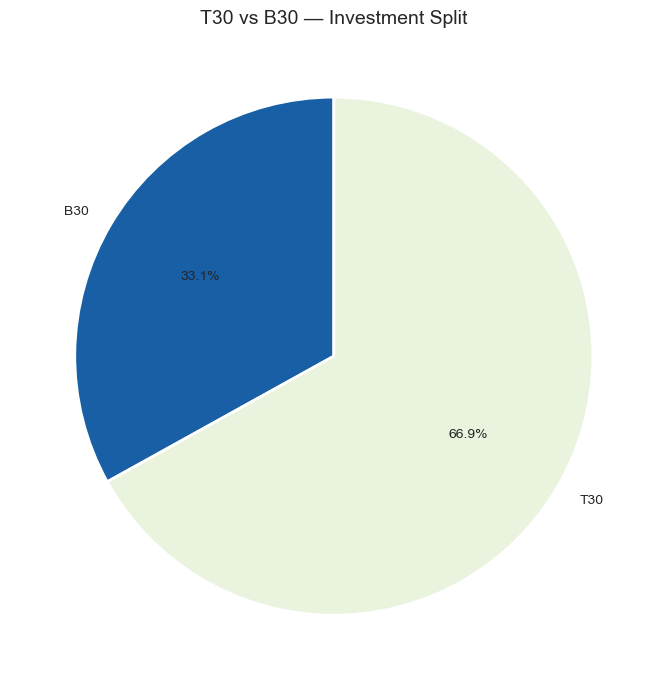

✓ Chart 8 done!


In [11]:
# T30 vs B30 pie chart
tier = transactions.groupby('city_tier')['amount_inr'].sum()

plt.figure(figsize=(7,7))
plt.pie(tier.values, labels=tier.index, autopct='%1.1f%%',
        colors=['#185FA5','#EAF3DE'], startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
plt.title('T30 vs B30 — Investment Split', fontsize=14)
plt.tight_layout()
plt.savefig('chart7_t30_b30.png', dpi=150)
plt.show()
print("✓ Chart 8 done!")

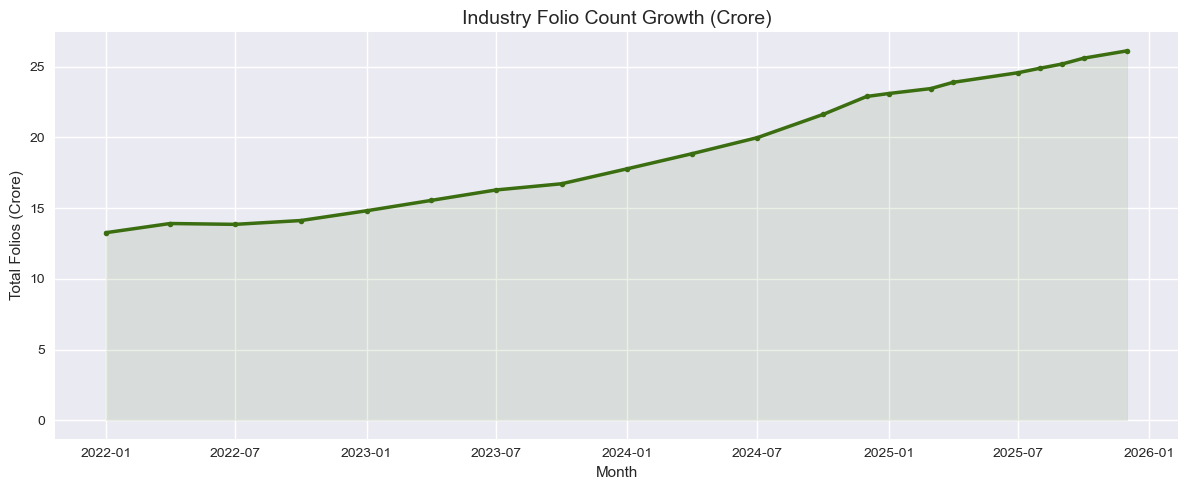

✓ Chart 9 done!


In [12]:
# Folio count growth
plt.figure(figsize=(12,5))
plt.plot(folio['month'], folio['total_folios_crore'],
         color='#3B6D11', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(folio['month'], folio['total_folios_crore'],
                 alpha=0.1, color='#3B6D11')
plt.title('Industry Folio Count Growth (Crore)', fontsize=14)
plt.ylabel('Total Folios (Crore)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('chart8_folio_growth.png', dpi=150)
plt.show()
print("✓ Chart 9 done!")

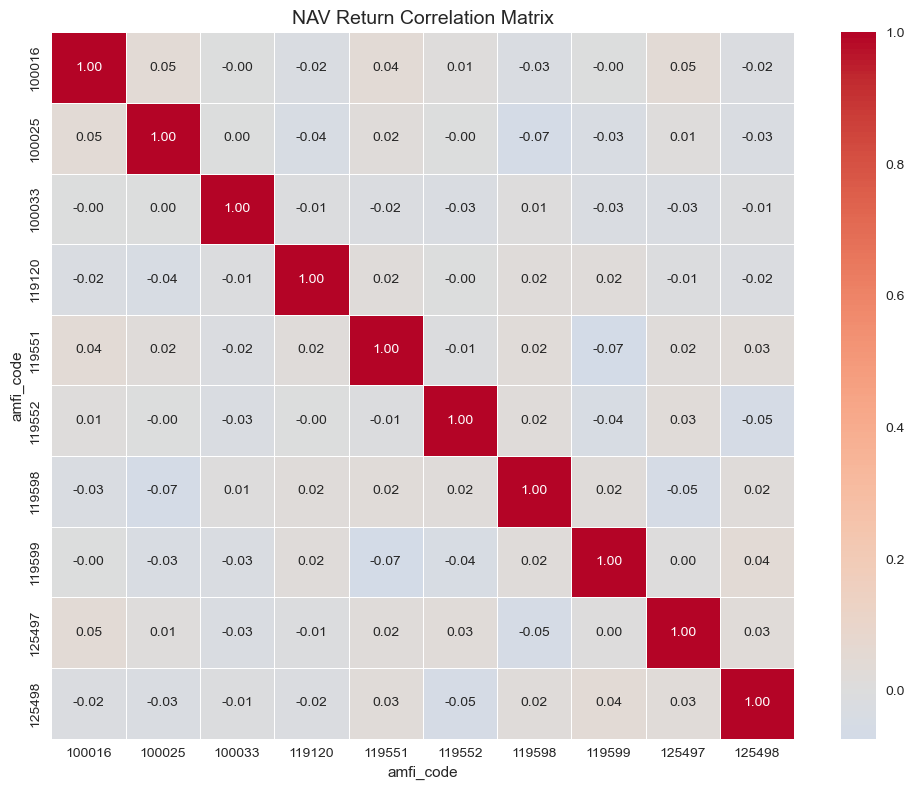

✓ Chart 10 done!


In [13]:
# NAV return correlation
top10 = nav['amfi_code'].unique()[:10]
nav10 = nav[nav['amfi_code'].isin(top10)].copy()
nav10['daily_return'] = nav10.groupby('amfi_code')['nav'].pct_change()

corr = nav10.pivot(index='date', columns='amfi_code',
                   values='daily_return').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('NAV Return Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('chart9_correlation.png', dpi=150)
plt.show()
print("✓ Chart 10 done!")

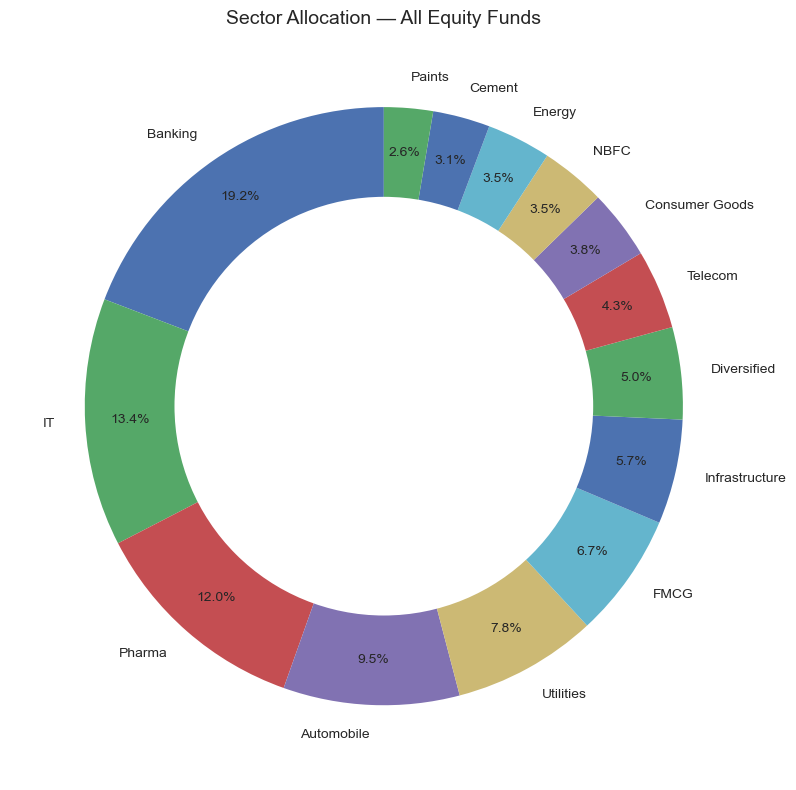

✓ Chart 11 done!


In [14]:
# Sector allocation donut
sector = holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,8))
wedges, texts, autotexts = plt.pie(
    sector.values, labels=sector.index,
    autopct='%1.1f%%', pctdistance=0.85, startangle=90)

centre = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre)
plt.title('Sector Allocation — All Equity Funds', fontsize=14)
plt.tight_layout()
plt.savefig('chart10_sector.png', dpi=150)
plt.show()
print("✓ Chart 11 done!")

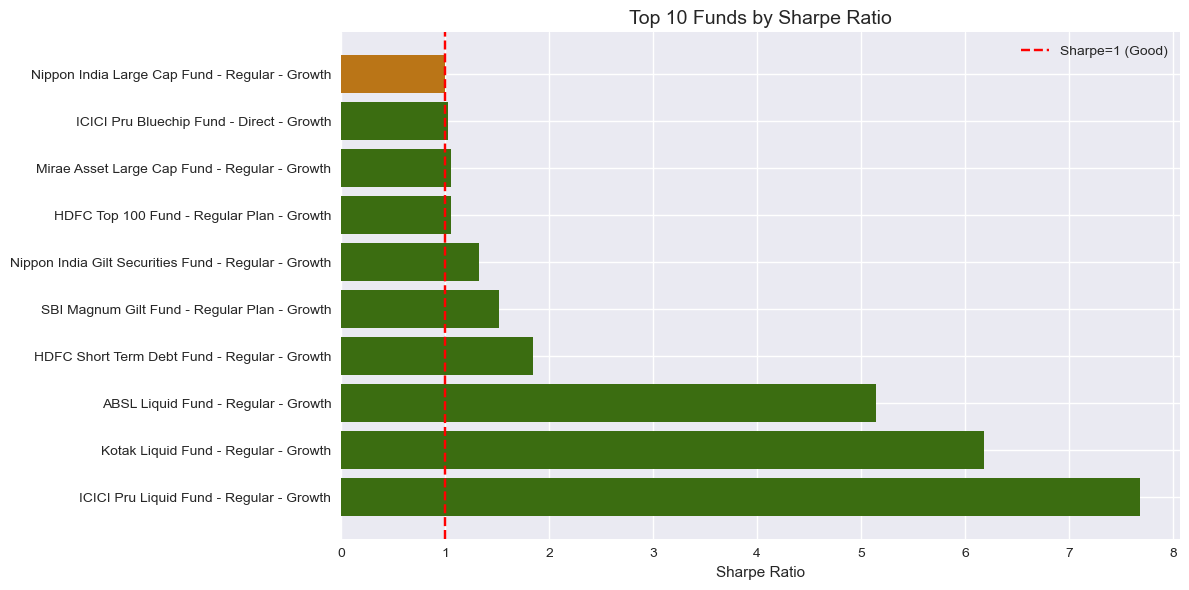

✓ Chart 12 done!


In [15]:
# Top 10 funds by Sharpe ratio
top_sharpe = performance.nlargest(10, 'sharpe_ratio')

plt.figure(figsize=(12,6))
plt.barh(top_sharpe['scheme_name'], top_sharpe['sharpe_ratio'],
         color=['#3B6D11' if x>1 else '#BA7517'
                for x in top_sharpe['sharpe_ratio']])
plt.axvline(x=1, color='red', linestyle='--', label='Sharpe=1 (Good)')
plt.title('Top 10 Funds by Sharpe Ratio', fontsize=14)
plt.xlabel('Sharpe Ratio')
plt.legend()
plt.tight_layout()
plt.savefig('chart11_sharpe.png', dpi=150)
plt.show()
print("✓ Chart 12 done!")

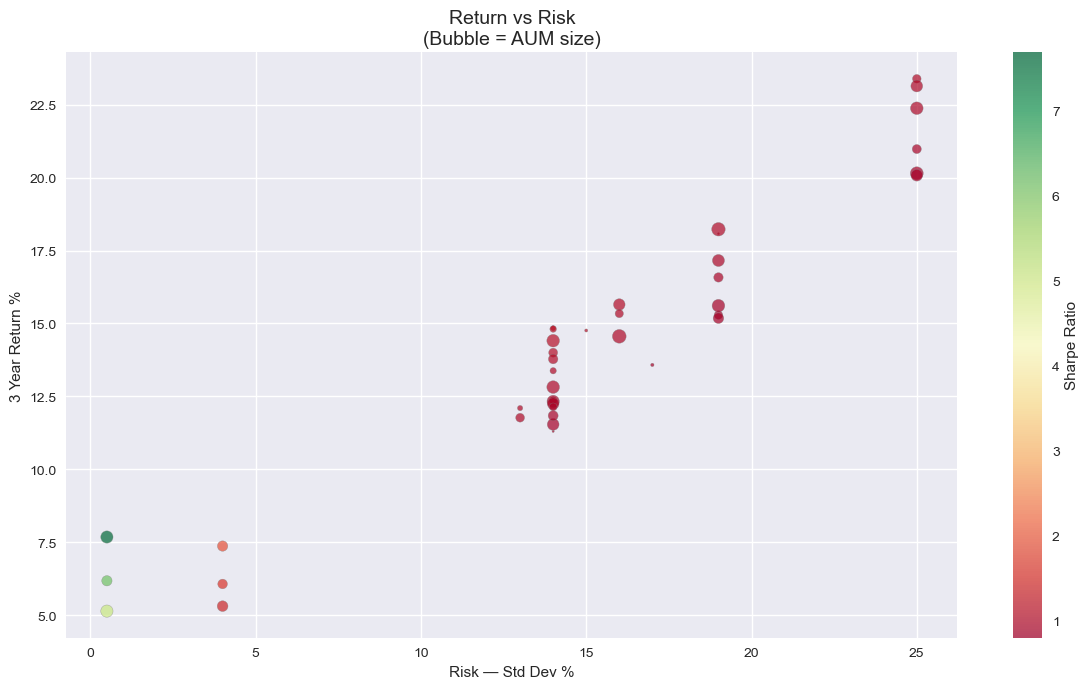

✓ Chart 13 done!


In [16]:
# Return vs Risk bubble chart
plt.figure(figsize=(12,7))
scatter = plt.scatter(
    performance['std_dev_ann_pct'],
    performance['return_3yr_pct'],
    s=performance['aum_crore']/500,
    c=performance['sharpe_ratio'],
    cmap='RdYlGn', alpha=0.7, edgecolors='gray')

plt.colorbar(scatter, label='Sharpe Ratio')
plt.title('Return vs Risk\n(Bubble = AUM size)', fontsize=14)
plt.xlabel('Risk — Std Dev %')
plt.ylabel('3 Year Return %')
plt.tight_layout()
plt.savefig('chart12_return_risk.png', dpi=150)
plt.show()
print("✓ Chart 13 done!")

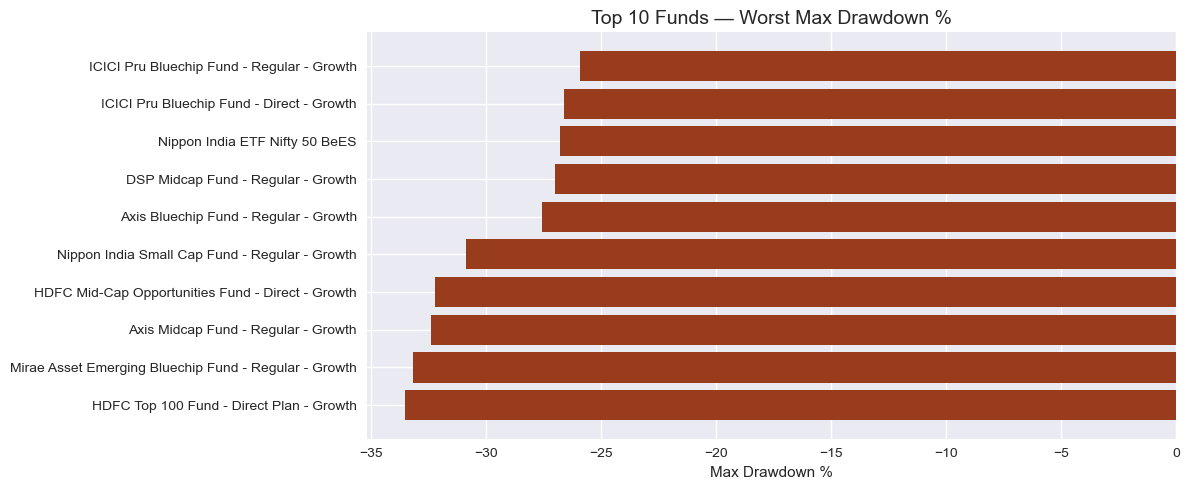

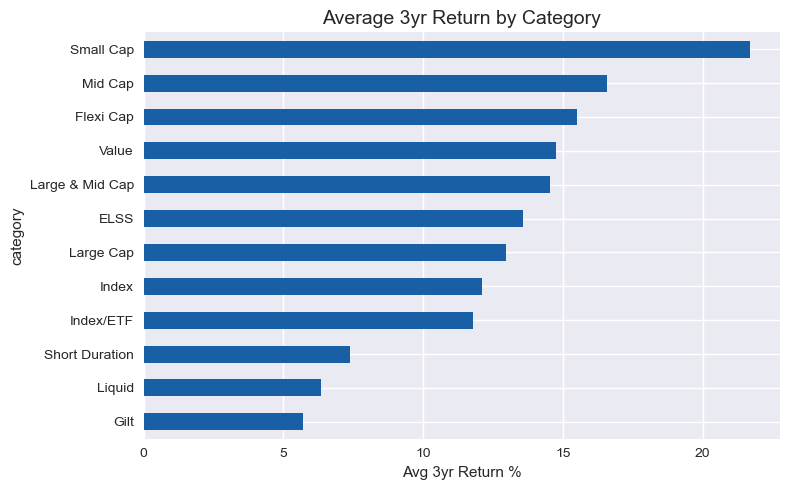

✓ Chart 14 & 15 done!


In [17]:
# Max drawdown worst funds
worst = performance.nsmallest(10, 'max_drawdown_pct')

plt.figure(figsize=(12,5))
plt.barh(worst['scheme_name'], worst['max_drawdown_pct'], color='#993C1D')
plt.title('Top 10 Funds — Worst Max Drawdown %', fontsize=14)
plt.xlabel('Max Drawdown %')
plt.tight_layout()
plt.savefig('chart13_drawdown.png', dpi=150)
plt.show()

# Category wise avg return
cat_ret = performance.groupby('category')['return_3yr_pct'].mean().sort_values()
plt.figure(figsize=(8,5))
cat_ret.plot(kind='barh', color='#185FA5')
plt.title('Average 3yr Return by Category', fontsize=14)
plt.xlabel('Avg 3yr Return %')
plt.tight_layout()
plt.savefig('chart14_category_returns.png', dpi=150)
plt.show()
print("✓ Chart 14 & 15 done!")

In [18]:
import os

charts = sorted([f for f in os.listdir('.') if f.endswith('.png')])
print(f"✓ Total {len(charts)} charts saved:")
for c in charts:
    print(f"  {c}")

print("\n🎉 EDA COMPLETE!")

✓ Total 28 charts saved:
  1BFY 24-25.png
  AIM Flow Chart - Hints & Glossary.png
  AIM Flow Chart.png
  Screenshot 2024-11-19 233320.png
  Screenshot 2024-12-04 104622.png
  Screenshot 2025-03-25 231223.png
  Screenshot 2025-11-06 213344.png
  Screenshot 2025-12-17 112331.png
  Screenshot 2026-01-16 140435.png
  Screenshot 2026-03-03 132646.png
  Screenshot 2026-03-03 134643.png
  Screenshot 2026-06-02 204337.png
  Screenshot 2026-06-04 141211.png
  chart10_sector.png
  chart11_sharpe.png
  chart12_return_risk.png
  chart13_drawdown.png
  chart14_category_returns.png
  chart1_nav_trend.png
  chart2_aum_growth.png
  chart3_sip_trend.png
  chart4_category_heatmap.png
  chart5_demographics.png
  chart6_state_sip.png
  chart7_t30_b30.png
  chart8_folio_growth.png
  chart9_correlation.png
  download.png

🎉 EDA COMPLETE!


# 10 Key EDA Findings — Bluestock MF Capstone
## Aman Karwal | June 2026

1. SBI MF dominates AUM — highest among all fund houses
2. SIP inflows hit all-time high of ₹31,002 Cr in Dec 2025
3. Large Cap category receives highest net inflows
4. 26-35 age group contributes maximum SIP transactions
5. T30 cities contribute ~70% of total investment
6. Maharashtra is top state for SIP contribution
7. Total folios doubled from 13.26 Cr to 26.12 Cr in 4 years
8. Large cap funds highly correlated (>0.85) — less diversification benefit
9. Banking & Financial Services is largest sector in equity portfolios
10. Only top 30% funds have Sharpe > 1 — rest underperform risk-adjusted

In [20]:
import os

charts = sorted([f for f in os.listdir('.') if f.endswith('.png')])
print(f"Total charts: {len(charts)}")
for c in charts:
    print(f"  {c}")

Total charts: 28
  1BFY 24-25.png
  AIM Flow Chart - Hints & Glossary.png
  AIM Flow Chart.png
  Screenshot 2024-11-19 233320.png
  Screenshot 2024-12-04 104622.png
  Screenshot 2025-03-25 231223.png
  Screenshot 2025-11-06 213344.png
  Screenshot 2025-12-17 112331.png
  Screenshot 2026-01-16 140435.png
  Screenshot 2026-03-03 132646.png
  Screenshot 2026-03-03 134643.png
  Screenshot 2026-06-02 204337.png
  Screenshot 2026-06-04 141211.png
  chart10_sector.png
  chart11_sharpe.png
  chart12_return_risk.png
  chart13_drawdown.png
  chart14_category_returns.png
  chart1_nav_trend.png
  chart2_aum_growth.png
  chart3_sip_trend.png
  chart4_category_heatmap.png
  chart5_demographics.png
  chart6_state_sip.png
  chart7_t30_b30.png
  chart8_folio_growth.png
  chart9_correlation.png
  download.png


In [21]:
import pandas as pd
import shutil, os

CSV = r"C:\Users\Aman Karwal\Downloads\bluestock-mf-capstone\\"
BASE = r"C:\Users\Aman Karwal\bluestock_mf_capstone\\"

# Power BI folder banao
PBI = BASE + "dashboard\\"
os.makedirs(PBI, exist_ok=True)

# Saari files copy karo dashboard folder mein
files = [
    "01_fund_master.csv",
    "02_nav_history.csv", 
    "03_aum_by_fund_house.csv",
    "04_monthly_sip_inflows.csv",
    "05_category_inflows.csv",
    "06_industry_folio_count.csv",
    "07_scheme_performance.csv",
    "08_investor_transactions.csv",
    "09_portfolio_holdings.csv",
    "10_benchmark_indices.csv"
]

for f in files:
    shutil.copy(CSV + f, PBI + f)
    print(f"✓ {f}")

# Scorecard bhi copy karo
src = r"C:\Users\Aman Karwal\fund_scorecard.csv"
if os.path.exists(src):
    shutil.copy(src, PBI + "fund_scorecard.csv")
    print("✓ fund_scorecard.csv")

print(f"\n✓ Sab ready hai Power BI ke liye!")
print(f"Folder: {PBI}")

✓ 01_fund_master.csv
✓ 02_nav_history.csv
✓ 03_aum_by_fund_house.csv
✓ 04_monthly_sip_inflows.csv
✓ 05_category_inflows.csv
✓ 06_industry_folio_count.csv
✓ 07_scheme_performance.csv
✓ 08_investor_transactions.csv
✓ 09_portfolio_holdings.csv
✓ 10_benchmark_indices.csv
✓ fund_scorecard.csv

✓ Sab ready hai Power BI ke liye!
Folder: C:\Users\Aman Karwal\bluestock_mf_capstone\\dashboard\
